# Tiled read

In this notebook, we will perform a visual analysis of the windowed read provided by rasterio. With windowed read, it is intended the capability to read only a sub-part of the raster, called a tile, and to iterate through all of them to reduce the space required in RAM to load the entire dataset at once. This feature is particularly useful when we have to operate on multiple scene of the same tile or with many bands at once. By reading only a small chunk of data from the entire raster, we can easily perform computations across multiple bands without bloating RAM.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import pathlib
import os

sys.path.append(os.path.abspath(".."))

In [10]:
from src.io import GLOBAL_CONFIG, RAW_DATA_DIR
from src.config import load_config

In [8]:
root, target = next(
    (root, file) for root, _, files in RAW_DATA_DIR.walk() for file in files
)

In [11]:
all_band_file = root / target
all_band_file

PosixPath('/Users/stepit/Repositories/projects/lu-lc-classification-with-unet/data/raw/MAM/S2A_MSIL2A_20220516T110631_N0510_R137_T30STG_20240617T123024_ALLBANDS.tif')

In [12]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

When opening a file with rasterio, we can get the [tiles size for the raster](https://rasterio.readthedocs.io/en/latest/topics/windowed-rw.html) with `src.block_shapes`.

In [16]:
with rasterio.open(all_band_file) as src:
    profile = src.profile
    block_shapes = src.block_shapes
block_shapes

[(1024, 1024),
 (1024, 1024),
 (1024, 1024),
 (1024, 1024),
 (1024, 1024),
 (1024, 1024),
 (1024, 1024),
 (1024, 1024),
 (1024, 1024),
 (1024, 1024),
 (1024, 1024)]

Since we also know that each scene has 5181 rows and 5169 columns, we can compute the number of tiles in each direction, and whether there will be any skewed tile. 

In [13]:
print(f"For columns direction: {5169 // 1024, 5169 % 1024}")
print(f"For rows direction: {5181 // 1024, 5181 % 1024}")

For columns direction: (5, 49)
For rows direction: (5, 61)


So, considering the columns direction, we will have 5 full tiles and 1 tile with only 49 pixels. 

The information about the window block size is controlled with the rasterio Profile properties `blockxsize` and `blockysize`:

In [17]:
profile["blockxsize"], profile["blockysize"]

(1024, 1024)

We can investigate how to use windowed read by considering the Green band of our raster:

In [18]:
with rasterio.open(all_band_file) as src:
    print(type(src))
    green = src.read(1)

<class 'rasterio.io.DatasetReader'>


In [19]:
p2 = np.nanpercentile(green, 2)
p98 = np.nanpercentile(green, 98)

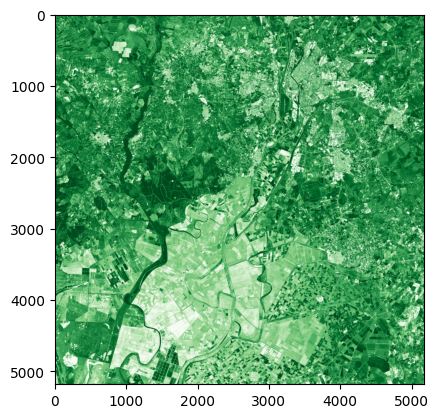

In [20]:
plt.imshow(green, vmin=p2, vmax=p98, cmap="Greens_r")

size is: (1024, 1024)
(0, 0): Window(col_off=0, row_off=0, width=1024, height=1024)
(0, 1): Window(col_off=1024, row_off=0, width=1024, height=1024)
(0, 2): Window(col_off=2048, row_off=0, width=1024, height=1024)
(0, 3): Window(col_off=3072, row_off=0, width=1024, height=1024)
(0, 4): Window(col_off=4096, row_off=0, width=1024, height=1024)
(0, 5): Window(col_off=5120, row_off=0, width=49, height=1024)
(1, 0): Window(col_off=0, row_off=1024, width=1024, height=1024)
(1, 1): Window(col_off=1024, row_off=1024, width=1024, height=1024)
(1, 2): Window(col_off=2048, row_off=1024, width=1024, height=1024)
(1, 3): Window(col_off=3072, row_off=1024, width=1024, height=1024)
(1, 4): Window(col_off=4096, row_off=1024, width=1024, height=1024)
(1, 5): Window(col_off=5120, row_off=1024, width=49, height=1024)


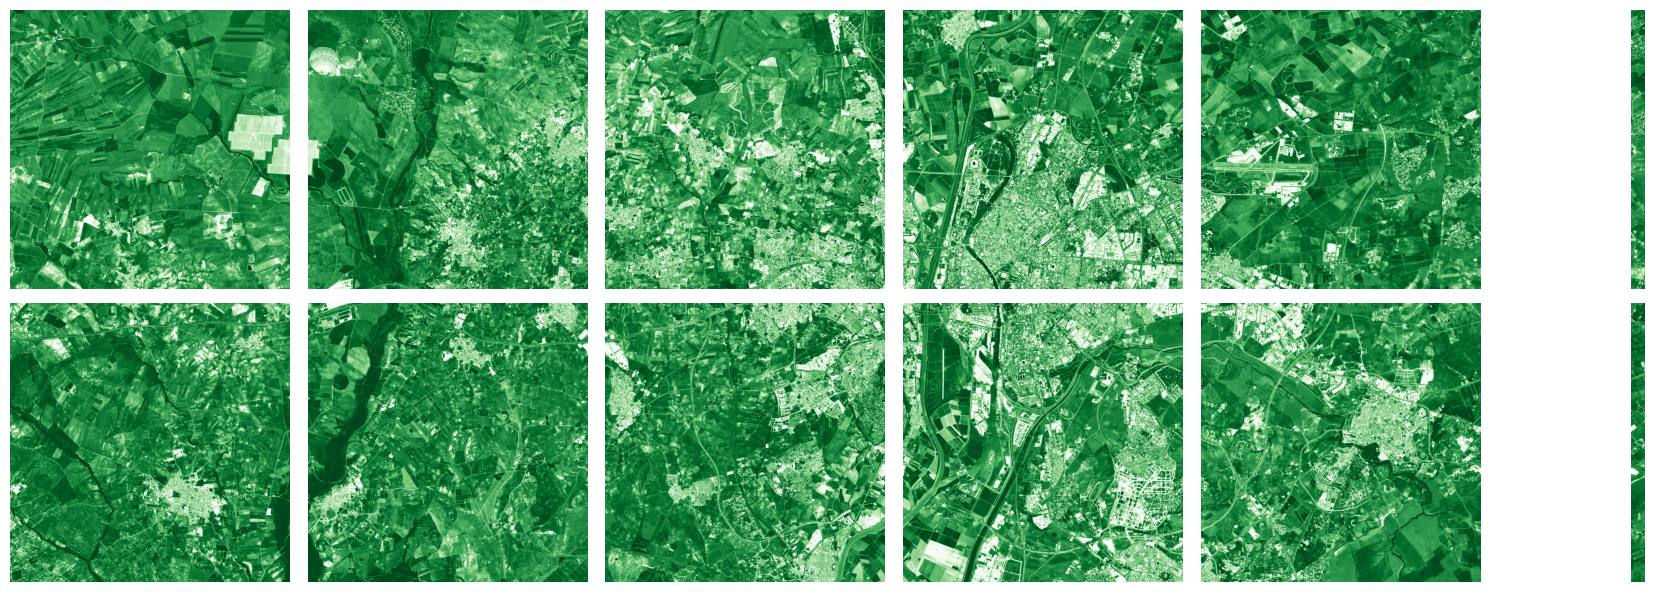

In [22]:
n_tiles = 10
fig, ax = plt.subplots(ncols=6, nrows=2, figsize=(18, 6))

row, col = 0, 0
with rasterio.open(all_band_file) as src:
    block_size = src.block_shapes[0]
    print(f"size is: {block_size}")

    for ji, window in src.block_windows(1):
        print(f"{ji}: {window}")
        data = src.read(1, window=window)

        if col == 6:
            row += 1

        ax[row, col % 6].imshow(data, vmin=p2, vmax=p98, cmap="Greens_r")
        ax[row, col % 6].axis("off")

        col += 1

        if col == 12:
            break

plt.tight_layout(pad=1)

As we can see, the last tile on each row is not full since it does not include enough pixels. The same is true also for the entire last row.